In [28]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver



In [6]:
load_dotenv()

True

In [16]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [17]:
from langgraph.graph.message import add_messages
class chatst(TypedDict):
    message:Annotated[list[BaseMessage],add_messages]
    

In [18]:
def chatnode(state:chatst):
    message=state['message']
    response=llm.invoke(message)
    return {'message':[response]}


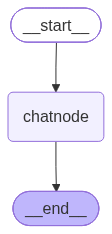

In [29]:
checkpoint=MemorySaver()
graph=StateGraph(chatst)

graph.add_node('chatnode',chatnode)
graph.add_edge(START,'chatnode')
graph.add_edge('chatnode',END)

chatbot=graph.compile(checkpointer=checkpoint)
chatbot

In [30]:
init={'message':[HumanMessage(content='Explain OOP IN C++')]}

In [24]:
respon=chatbot.invoke(init)
respon['message'][-1].content

'## Object‑Oriented Programming (OOP) in C++\n\nC++ is a multi‑paradigm language, but one of its strongest features is support for **Object‑Oriented Programming** (OOP). OOP lets you model real‑world entities as *objects* that encapsulate data (state) and behavior (functions). The core OOP concepts are:\n\n| Concept | What it is | Why it matters in C++ |\n|---------|------------|-----------------------|\n| **Class** | A blueprint that defines data members and member functions. | The building block of objects. |\n| **Object** | An instance of a class. | Represents a concrete entity. |\n| **Encapsulation** | Hiding internal state behind a public interface. | Protects data, reduces coupling. |\n| **Inheritance** | Reusing and extending a base class. | Enables “is‑a” relationships. |\n| **Polymorphism** | Using a common interface to invoke different implementations. | Enables dynamic behavior. |\n| **Abstraction** | Exposing only essential features. | Simplifies complex systems. |\n\nBelow

In [31]:
thread_id='1' #id for user blocks will be crwated for diff id

while True:
    user_message=input('type here: ')
    print('user: ',user_message)
    if user_message.strip().lower() in ['exit','quit','bye']:
        break
    config={'configurable':{'thread_id':thread_id}}
    response=chatbot.invoke({'message': [HumanMessage(content=user_message)]},config=config)
    print('AI: ',response['message'][-1].content)

user:  hi my name is khushi sharma
AI:  Hello Khushi! 👋 How can I help you today?
user:  whats my name
AI:  Your name is Khushi Sharma.
user:  bye
